# Self-Pruning Neural Network on CIFAR-10
### Tredence Studio AI Engineering Internship — 2025 Cohort

This notebook implements a feed-forward neural network that learns to prune its own
weights during training. Each weight has an associated learnable gate parameter.
The gate is driven toward zero by a sparsity regularisation term, which effectively
removes the corresponding weight from the computation.

**Platform:** Kaggle Notebook with GPU (T4 x2 or P100)

**Core mechanism:**  
Total Loss = CrossEntropyLoss + lambda * SparsityLoss  
SparsityLoss = mean of all gate values (normalised L1 norm)


In [1]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM            : {total_mem:.1f} GB")
    if total_mem < 12:
        print("\nWarning: less than 12 GB VRAM. Consider setting batch_size = 128 in CFG.")
    else:
        print("\nSufficient VRAM for batch_size = 256.")
else:
    print("\nNo GPU detected. Go to Settings -> Accelerator -> GPU T4 x2.")


Wed Apr 22 11:56:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os

BASE_DIR    = '/kaggle/working/self_pruning_network'
SAVE_DIR    = os.path.join(BASE_DIR, 'checkpoints')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')

os.makedirs(SAVE_DIR,    exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Base directory    : {BASE_DIR}")
print(f"Checkpoints saved : {SAVE_DIR}")
print(f"Plots and JSON    : {RESULTS_DIR}")
print(f"\nAfter training, download outputs from the Kaggle Output tab.")


Base directory    : /kaggle/working/self_pruning_network
Checkpoints saved : /kaggle/working/self_pruning_network/checkpoints
Plots and JSON    : /kaggle/working/self_pruning_network/results

After training, download outputs from the Kaggle Output tab.


## Step 3 — Imports and Reproducibility


In [3]:
import math
import json
import random
import os
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler, autocast

import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import autoaugment

import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {DEVICE}")

def set_seed(seed=42):
    """Fix all random sources so that results are reproducible across runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(42)
print("Seed set to 42.")


Running on: cuda
Seed set to 42.


## Step 4 — Hyperparameter Configuration

All tunable values are collected here. Every other cell reads from `CFG` so that
changing a single entry is enough to affect the entire run.


In [4]:
CFG = {
    # Training schedule
    'batch_size'   : 256,    # Fits comfortably on a T4 16 GB GPU.
    'num_epochs'   : 100,    # 100 epochs is sufficient for convergence on CIFAR-10.
    'lr'           : 0.1,    # Peak learning rate used by OneCycleLR.
    'momentum'     : 0.9,
    'weight_decay' : 5e-4,
    'patience'     : 20,     # Early stopping: halt if no improvement for 20 epochs.
    'num_workers'  : 4,

    # Augmentation
    'use_autoaugment': True,
    'use_mixup'      : True,
    'mixup_alpha'    : 0.2,
    'cutout_length'  : 16,

    # Architecture
    'label_smoothing': 0.1,

    # Gate initialisation.
    # sigmoid(2.0) ≈ 0.88 — every gate starts slightly "on" so the network can
    # first learn which connections are useful before the sparsity penalty kicks in.
    # Starting at 0.5 (gate_init=0.0) puts gates in a neutral midpoint where the
    # classification gradient and sparsity gradient cancel exactly, leaving gates
    # frozen. Starting at 0.88 gives classification a head start.
    'gate_init'    : 2.0,

    # Lambda values to compare.
    # All three sit in the range where the sparsity gradient (lambda * sigma_prime)
    # is small enough for trained important connections to resist pruning, yet
    # large enough to push idle connections across the 0.01 threshold.
    'lambda_values': [0.01, 0.03, 0.1],

    # Gate-specific optimiser settings.
    # gate_lr_mult:      gate_scores are updated with this multiple of the base LR.
    #                    A higher rate lets gates converge in the same wall-clock
    #                    time as the weights.
    # lambda_warmup_epochs: for this many epochs the effective lambda is ramped
    #                    linearly from 0 to the target value.  During warmup the
    #                    network is free to learn a strong representation; sparsity
    #                    pressure is introduced only after connections have had a
    #                    chance to differentiate themselves.
    'gate_lr_mult'         : 3.0,
    'lambda_warmup_epochs' : 20,

    # Mixed-precision training via AMP for roughly 2x throughput on Tensor Cores.
    'use_amp'      : True,
}

print("Configuration loaded:")
for k, v in CFG.items():
    print(f"  {k:<28} = {v}")


Configuration loaded:
  batch_size                   = 256
  num_epochs                   = 100
  lr                           = 0.1
  momentum                     = 0.9
  weight_decay                 = 0.0005
  patience                     = 20
  num_workers                  = 4
  use_autoaugment              = True
  use_mixup                    = True
  mixup_alpha                  = 0.2
  cutout_length                = 16
  label_smoothing              = 0.1
  gate_init                    = 2.0
  lambda_values                = [0.01, 0.03, 0.1]
  gate_lr_mult                 = 3.0
  lambda_warmup_epochs         = 20
  use_amp                      = True


## Step 5 — PrunableLinear Layer

This is the core building block of the self-pruning network.
Each weight in the layer has a paired learnable gate score.
The gate value (sigmoid of the score) multiplies the weight before the
linear transformation. When a gate reaches zero, that weight is silenced.


In [5]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class PrunableLinear(nn.Module):
    """
    A linear layer where every weight has a paired learnable gate.

    Forward pass:
        gates          = sigmoid(gate_scores)      — values in (0, 1)
        pruned_weights = weight * gates            — element-wise mask
        output         = F.linear(x, pruned_weights, bias)

    When a gate falls below the pruning threshold (0.01), the corresponding
    weight contributes essentially nothing to the output.  The sparsity loss
    provides the gradient that drives gates toward zero.

    Both weight and gate_scores are registered nn.Parameters, so the optimiser
    updates both tensors.  Gradients flow correctly through the sigmoid and
    the element-wise multiplication.
    """

    def __init__(self, in_features, out_features, bias=True, gate_init=0.0):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features

        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.bias   = nn.Parameter(torch.Tensor(out_features)) if bias else None

        # One gate score per weight entry, same shape as the weight matrix.
        self.gate_scores = nn.Parameter(torch.Tensor(out_features, in_features))

        self._init_params(gate_init)

    def _init_params(self, gate_init):
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
            nn.init.uniform_(self.bias, -bound, bound)
        # All gates start at sigmoid(gate_init).  With gate_init=2.0 that is
        # 0.88 — biased slightly "on" so classification can establish itself
        # before pruning pressure is applied.
        nn.init.constant_(self.gate_scores, gate_init)

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

    def get_gates(self):
        """Return gate values (detached) for inspection — does not affect gradients."""
        return torch.sigmoid(self.gate_scores).detach()

    def get_sparsity_loss(self):
        """
        Compute the L1 sparsity penalty for this layer.

        We use the SUM of gate values, not the mean.

        Why sum and not mean?
        The per-gate gradient of the sparsity loss w.r.t. gate_score_i is:
            d(sparsity) / d(gs_i) = lambda * sigma'(gs_i)

        With sum():  this equals  lambda * sigma'(gs_i)          — constant per gate
        With mean(): this equals  lambda * sigma'(gs_i) / N       — divided by layer size

        For fc1 (N = 4,194,304) the mean formulation gives a gradient of roughly
        lambda * 1e-7, which is nine orders of magnitude smaller than the
        classification gradient and effectively vanishes.  The sum formulation
        keeps the per-gate gradient independent of layer size, so the competition
        between sparsity and classification is the same in every layer.
        """
        gates = torch.sigmoid(self.gate_scores)
        return gates.sum()

    def extra_repr(self):
        return f'in_features={self.in_features}, out_features={self.out_features}'


# Sanity check: gradients must flow to both weight and gate_scores.
_layer = PrunableLinear(10, 5)
_x     = torch.randn(2, 10)
_out   = _layer(_x)
_out.sum().backward()

assert _layer.weight.grad      is not None, "weight gradient is missing"
assert _layer.gate_scores.grad is not None, "gate_scores gradient is missing"

print("PrunableLinear sanity check passed.")
print(f"  Output shape       : {_out.shape}")
print(f"  weight.grad exists : True")
print(f"  gate_scores.grad   : True")

# Show what the per-gate sparsity gradient will actually look like.
import math
sigma_prime = lambda gs: math.exp(-gs) / (1 + math.exp(-gs))**2
print()
print("Per-gate sparsity gradient magnitudes (lambda=0.03, sum formulation):")
for gs, label in [(2.0, "init gs=2.0"), (0.0, "gs=0.0"), (-3.0, "gs=-3.0")]:
    print(f"  {label}: {0.03 * sigma_prime(gs):.5f}")
del _layer, _x, _out


PrunableLinear sanity check passed.
  Output shape       : torch.Size([2, 5])
  weight.grad exists : True
  gate_scores.grad   : True

Per-gate sparsity gradient magnitudes (lambda=0.03, sum formulation):
  init gs=2.0: 0.00315
  gs=0.0: 0.00750
  gs=-3.0: 0.00136


## Step 6 — Network Architecture

The network has two parts:

1. **Convolutional feature extractor** — three standard VGG-style blocks that
   reduce the 32x32 image to a 256-channel 4x4 feature map. These layers use
   ordinary `nn.Conv2d` and are not subject to gate-based pruning.

2. **Prunable classification head** — three `PrunableLinear` layers (4096 -> 1024,
   1024 -> 512, 512 -> 10). Every weight in these layers is gated. With ~4.7M
   prunable parameters out of ~5.3M total, roughly 89% of the network can be
   selectively removed by the sparsity regularisation.

Using most of the network's capacity in the prunable head is an intentional design
choice: it ensures that the gate mechanism has meaningful impact on model behaviour
and that the sparsity-accuracy trade-off is clearly visible.


In [6]:
class SelfPruningNet(nn.Module):
    """
    A convolutional network for CIFAR-10 with a fully prunable classifier head.

    Architecture:
        Conv block 1  :  3  x 32x32  ->  64 x 16x16  (2 conv layers + max-pool)
        Conv block 2  :  64 x 16x16  -> 128 x  8x8   (2 conv layers + max-pool)
        Conv block 3  : 128 x  8x8   -> 256 x  4x4   (1 conv layer  + max-pool)
        Flatten       :  256 * 4 * 4 = 4096 features
        PrunableLinear:  4096 -> 1024
        PrunableLinear:  1024 ->  512
        PrunableLinear:   512 ->   10  (class logits)

    The convolutional layers are standard nn.Conv2d and are not gated.
    All three fully-connected layers are PrunableLinear, so approximately
    89% of the total parameters are subject to gate-based pruning.
    """

    def __init__(self, num_classes=10, gate_init=0.0):
        super().__init__()

        # Convolutional feature extractor.
        # Each block halves the spatial resolution while increasing channel depth,
        # following the standard pattern used in VGG-style networks.
        self.features = nn.Sequential(
            # Block 1: 3 x 32x32 -> 64 x 16x16
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2: 64 x 16x16 -> 128 x 8x8
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3: 128 x 8x8 -> 256 x 4x4
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        # After the conv blocks: 256 channels over a 4x4 spatial grid = 4096 features.

        # Prunable classification head.
        # Using PrunableLinear for every FC layer means the gate mechanism can
        # independently suppress any connection that does not contribute to accuracy.
        self.fc1     = PrunableLinear(256 * 4 * 4, 1024, gate_init=gate_init)
        self.bn_fc1  = nn.BatchNorm1d(1024)
        self.fc2     = PrunableLinear(1024, 512, gate_init=gate_init)
        self.bn_fc2  = nn.BatchNorm1d(512)
        self.fc3     = PrunableLinear(512, num_classes, gate_init=gate_init)
        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        # Run the convolutional feature extractor.
        x = self.features(x)
        # Flatten the 256x4x4 feature map into a vector of length 4096.
        x = x.view(x.size(0), -1)
        # First prunable layer: 4096 -> 1024 with batch norm and ReLU.
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout(x)
        # Second prunable layer: 1024 -> 512 with batch norm and ReLU.
        x = F.relu(self.bn_fc2(self.fc2(x)))
        # Final prunable layer: 512 -> 10. No activation; outputs are raw logits.
        x = self.fc3(x)
        return x

    def get_total_sparsity_loss(self):
        """Sum the normalised L1 penalty across every PrunableLinear layer."""
        return sum(m.get_sparsity_loss()
                   for m in self.modules() if isinstance(m, PrunableLinear))

    def calculate_sparsity(self, threshold=1e-2):
        """
        Return the percentage of gates whose value is below the pruning threshold.

        A gate below 0.01 contributes less than 1% of the original weight value
        to the linear transformation and is considered effectively pruned.
        """
        total = pruned = 0
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                g      = m.get_gates()
                total  += g.numel()
                pruned += (g < threshold).sum().item()
        return 100.0 * pruned / total if total else 0.0

    def get_all_gate_values(self):
        """Collect all gate values across every PrunableLinear layer into one array."""
        values = []
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                values.extend(m.get_gates().detach().cpu().numpy().flatten())
        return np.array(values)

    def count_parameters(self):
        total    = sum(p.numel() for p in self.parameters())
        prunable = sum(m.weight.numel() for m in self.modules()
                       if isinstance(m, PrunableLinear))
        return total, prunable


# Print a brief parameter summary to confirm the architecture is correct.
_model = SelfPruningNet(gate_init=CFG['gate_init']).to(DEVICE)
total, prunable = _model.count_parameters()
print("SelfPruningNet created.")
print(f"  Total parameters    : {total:,}")
print(f"  Prunable parameters : {prunable:,}  ({100 * prunable / total:.1f}% of total)")
del _model


SelfPruningNet created.
  Total parameters    : 10,008,650
  Prunable parameters : 4,723,712  (47.2% of total)


## Step 7 — Data Pipeline

CIFAR-10 contains 50,000 training images and 10,000 test images across 10 classes.
The training pipeline applies several augmentations to reduce overfitting:
RandomCrop, HFlip, AutoAugment (the policy specifically tuned for CIFAR-10),
MixUp (applied stochastically at the batch level), and Cutout.
The test pipeline applies only normalisation.


In [7]:
class Cutout:
    """
    Randomly erases a square region of an image by setting those pixels to zero.
    This forces the model to rely on distributed rather than localised cues,
    which tends to improve generalisation.
    """
    def __init__(self, n_holes=1, length=16):
        self.n_holes = n_holes
        self.length  = length

    def __call__(self, img):
        h, w = img.size(1), img.size(2)
        mask = np.ones((h, w), dtype=np.float32)
        for _ in range(self.n_holes):
            y, x = np.random.randint(h), np.random.randint(w)
            y1 = max(0, y - self.length // 2)
            y2 = min(h, y + self.length // 2)
            x1 = max(0, x - self.length // 2)
            x2 = min(w, x + self.length // 2)
            mask[y1:y2, x1:x2] = 0.0
        return img * torch.from_numpy(mask).expand_as(img)


def mixup_data(x, y, alpha=0.2):
    """
    Linearly interpolate two mini-batches using a Beta-distributed coefficient.
    Returns the mixed images along with both sets of labels and the mixing ratio.
    """
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam


def mixup_loss(criterion, pred, ya, yb, lam):
    """Compute the cross-entropy loss for a MixUp batch as a weighted average."""
    return lam * criterion(pred, ya) + (1 - lam) * criterion(pred, yb)


def load_cifar10(batch_size, num_workers):
    """
    Build CIFAR-10 data loaders with the standard augmentation pipeline.

    Training  : RandomCrop -> HFlip -> AutoAugment -> ToTensor -> Normalise -> Cutout
    Evaluation: ToTensor -> Normalise
    """
    mean = (0.4914, 0.4822, 0.4465)
    std  = (0.2470, 0.2435, 0.2616)

    train_tf = transforms.Compose([
        transforms.RandomCrop(32, padding=4, padding_mode='reflect'),
        transforms.RandomHorizontalFlip(),
        autoaugment.AutoAugment(autoaugment.AutoAugmentPolicy.CIFAR10),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
        Cutout(n_holes=1, length=CFG['cutout_length']),
    ])

    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    trainset = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=train_tf)
    testset  = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=test_tf)

    trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True,
                             num_workers=num_workers, pin_memory=True,
                             persistent_workers=True)
    testloader  = DataLoader(testset,  batch_size=batch_size, shuffle=False,
                             num_workers=num_workers, pin_memory=True,
                             persistent_workers=True)
    return trainloader, testloader


_train, _test = load_cifar10(CFG['batch_size'], CFG['num_workers'])
print("CIFAR-10 loaded.")
print(f"  Training batches : {len(_train)}  (50,000 samples, batch size {CFG['batch_size']})")
print(f"  Test batches     : {len(_test)}   (10,000 samples)")


100%|██████████| 170M/170M [00:01<00:00, 86.6MB/s] 


CIFAR-10 loaded.
  Training batches : 196  (50,000 samples, batch size 256)
  Test batches     : 40   (10,000 samples)


## Step 8 — Training and Evaluation Functions

`train_epoch` runs one full pass over the training set.
For each mini-batch it computes:

    total_loss = cross_entropy_loss + lambda * sparsity_loss

where `sparsity_loss` is the mean gate value across all `PrunableLinear` layers.
Both the weight parameters and the gate_score parameters are updated by the
backward pass, so the network simultaneously learns to classify and to prune.


In [8]:
def train_epoch(model, loader,
                weight_optimizer, gate_optimizer,
                weight_scheduler, criterion,
                lambda_s, scaler, epoch, use_amp, use_mixup,
                warmup_epochs):
    """
    Run one full training epoch with dual optimisers and lambda warm-up.

    The lambda warm-up is the key change that lets high lambda values work safely.
    For the first warmup_epochs the network trains with no sparsity pressure at all.
    The penalty then ramps up linearly so that by epoch warmup_epochs the full
    lambda is active.  By that point the network has learned which connections
    matter and the classification gradient on important gates is strong enough to
    hold them open against the sparsity pull.

    Two separate optimisers are used because gate_scores and weights need
    different treatment:
      weight_optimizer  — SGD with weight decay and OneCycleLR schedule
      gate_optimizer    — SGD with NO weight decay and a higher base LR

    Weight decay was the hidden killer in every previous version.  SGD applies
    weight decay by adding  wd * gate_score  to the gradient.  When a gate_score
    is negative (gate < 0.5), this term is also negative, meaning it points in the
    same direction as the weight update — away from zero.  That creates a stable
    equilibrium at some gate value well above 0.01 so gates never reach the
    pruning threshold.  Removing weight decay from gate_scores lets them drift
    toward -infinity for connections that are not needed.
    """
    model.train()
    total_loss = cls_loss_sum = sparse_loss_sum = 0.0
    correct = seen = 0

    # Linear ramp: epoch 1 → 0 lambda, epoch warmup_epochs+1 → full lambda.
    warmup_frac     = min(1.0, (epoch - 1) / max(1, warmup_epochs))
    effective_lambda = lambda_s * warmup_frac

    pbar = tqdm(loader, desc=f'  Epoch {epoch:3d}', leave=False)
    for imgs, labels in pbar:
        imgs   = imgs.to(DEVICE,   non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        use_mx = use_mixup and (random.random() < 0.5)
        if use_mx:
            imgs, ya, yb, lam = mixup_data(imgs, labels, CFG['mixup_alpha'])

        weight_optimizer.zero_grad(set_to_none=True)
        gate_optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=use_amp):
            outputs  = model(imgs)
            cls_loss = mixup_loss(criterion, outputs, ya, yb, lam) if use_mx \
                       else criterion(outputs, labels)
            sparse_loss = model.get_total_sparsity_loss()
            loss        = cls_loss + effective_lambda * sparse_loss

        scaler.scale(loss).backward()

        # Clip weight gradients to stabilise early training.
        # Gate gradients are NOT clipped — they are already small and we do not
        # want to suppress the sparsity signal any further.
        scaler.unscale_(weight_optimizer)
        weight_params = [p for n, p in model.named_parameters()
                         if 'gate_scores' not in n]
        torch.nn.utils.clip_grad_norm_(weight_params, 1.0)

        scaler.unscale_(gate_optimizer)
        scaler.step(weight_optimizer)
        scaler.step(gate_optimizer)
        scaler.update()
        weight_scheduler.step()

        total_loss      += loss.item()
        cls_loss_sum    += cls_loss.item()
        sparse_loss_sum += sparse_loss.item()
        _, pred  = outputs.max(1)
        seen    += labels.size(0)
        correct += pred.eq(labels).sum().item()

        pbar.set_postfix(
            loss    = f'{loss.item():.3f}',
            sparse  = f'{effective_lambda:.4f}x{sparse_loss.item():.1f}',
            acc     = f'{100. * correct / seen:.1f}%',
        )

    n = len(loader)
    return total_loss / n, cls_loss_sum / n, sparse_loss_sum / n, 100. * correct / seen


@torch.no_grad()
def evaluate(model, loader, criterion, use_amp):
    """Measure cross-entropy loss and top-1 accuracy on the given loader."""
    model.eval()
    loss_sum = correct = seen = 0
    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE,   non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        with autocast(enabled=use_amp):
            out  = model(imgs)
            loss = criterion(out, labels)
        loss_sum += loss.item()
        _, pred   = out.max(1)
        seen     += labels.size(0)
        correct  += pred.eq(labels).sum().item()
    return loss_sum / len(loader), 100. * correct / seen


print("train_epoch and evaluate are ready.")


train_epoch and evaluate are ready.


## Step 9 — Full Training Pipeline

`train_model` trains one model for a given lambda value. It handles the full
lifecycle: model construction, optimizer setup, the training loop, early stopping,
checkpoint saving, and final evaluation of the best saved weights.


In [9]:
def train_model(lambda_sparsity, save_dir=SAVE_DIR):
    """
    Full training run for a single lambda value.

    Key structural changes vs the original:

    1.  gate_scores parameters are separated into their own param group with
        - weight_decay = 0.0   (removes the restoring force that blocked pruning)
        - lr scaled by gate_lr_mult  (lets gates converge at the same pace as weights)

    2.  A separate gate_optimizer (SGD, no schedule) is used so the two sets of
        parameters can be managed independently without interfering with each other's
        gradient statistics.

    3.  lambda_warmup_epochs ensures the network trains cleanly before sparsity
        pressure is introduced.

    Everything else (OneCycleLR, AMP, early stopping, checkpointing) is unchanged.
    """
    set_seed(42)

    trainloader, testloader = load_cifar10(CFG['batch_size'], CFG['num_workers'])

    model = SelfPruningNet(gate_init=CFG['gate_init']).to(DEVICE)
    total, prunable = model.count_parameters()
    print(f"  Parameters: {total:,} total | {prunable:,} prunable ({100 * prunable / total:.1f}%)")

    criterion = nn.CrossEntropyLoss(label_smoothing=CFG['label_smoothing'])

    # Split parameters into two groups so we can give gate_scores zero weight
    # decay and a higher learning rate without affecting the weight parameters.
    weight_params = [p for n, p in model.named_parameters() if 'gate_scores' not in n]
    gate_params   = [p for n, p in model.named_parameters() if 'gate_scores' in n]

    print(f"  Weight param tensors : {len(weight_params)}")
    print(f"  Gate param tensors   : {len(gate_params)}")

    # Primary optimiser for all weights and biases (and BN params).
    # Weight decay is kept here for regularisation.
    weight_optimizer = optim.SGD(
        weight_params,
        lr           = CFG['lr'],
        momentum     = CFG['momentum'],
        weight_decay = CFG['weight_decay'],
        nesterov     = True,
    )

    # Gate optimiser: no weight decay, higher LR via gate_lr_mult.
    # Using a flat cosine schedule rather than OneCycleLR because:
    #   - gates do not benefit from the warmup phase (they have their own lambda warmup)
    #   - a steadily decaying LR gives gates the most movement early where it matters
    gate_lr = CFG['lr'] * CFG['gate_lr_mult']
    gate_optimizer = optim.SGD(
        gate_params,
        lr           = gate_lr,
        momentum     = CFG['momentum'],
        weight_decay = 0.0,   # critical — zero weight decay on gates
        nesterov     = True,
    )

    # OneCycleLR for the weight optimiser only.
    weight_scheduler = optim.lr_scheduler.OneCycleLR(
        weight_optimizer,
        max_lr           = CFG['lr'],
        epochs           = CFG['num_epochs'],
        steps_per_epoch  = len(trainloader),
        pct_start        = 0.3,
        anneal_strategy  = 'cos',
        div_factor       = 25.0,
        final_div_factor = 1e4,
    )

    # Cosine annealing for the gate optimiser: starts at gate_lr, decays to ~0.
    # T_max is in epochs — this scheduler is stepped once per epoch below.
    gate_scheduler = optim.lr_scheduler.CosineAnnealingLR(
        gate_optimizer,
        T_max   = CFG['num_epochs'],
        eta_min = gate_lr * 1e-3,
    )

    scaler = GradScaler(enabled=CFG['use_amp'])

    history = dict(train_acc=[], test_acc=[], train_loss=[],
                   test_loss=[], sparsity=[], lr=[])

    best_acc     = 0.0
    patience_ctr = 0
    ckpt_path    = os.path.join(save_dir, f'best_lambda_{lambda_sparsity}.pth')

    print(f"  lambda             : {lambda_sparsity}")
    print(f"  warmup epochs      : {CFG['lambda_warmup_epochs']}")
    print(f"  gate LR            : {gate_lr:.4f} ({CFG['gate_lr_mult']}x base LR)")
    print(f"  Checkpoint         : {ckpt_path}")
    print(f"  {'Epoch':>6} | {'Train':>7} | {'Test':>7} | {'Sparsity':>9} | {'LR':>9}")
    print(f"  {'-'*52}")

    for epoch in range(1, CFG['num_epochs'] + 1):

        tr_loss, _, _, tr_acc = train_epoch(
            model, trainloader,
            weight_optimizer, gate_optimizer,
            weight_scheduler, criterion,
            lambda_sparsity, scaler, epoch,
            use_amp       = CFG['use_amp'],
            use_mixup     = CFG['use_mixup'],
            warmup_epochs = CFG['lambda_warmup_epochs'],
        )
        gate_scheduler.step()

        te_loss, te_acc = evaluate(model, testloader, criterion, CFG['use_amp'])
        sparsity        = model.calculate_sparsity()
        cur_lr          = weight_optimizer.param_groups[0]['lr']

        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)
        history['train_loss'].append(tr_loss)
        history['test_loss'].append(te_loss)
        history['sparsity'].append(sparsity)
        history['lr'].append(cur_lr)

        if epoch <= 5 or epoch % 10 == 0 or epoch == CFG['lambda_warmup_epochs']:
            print(f"  {epoch:6d} | {tr_acc:6.2f}% | {te_acc:6.2f}% | "
                  f"{sparsity:8.2f}% | {cur_lr:.2e}")

        if te_acc > best_acc:
            best_acc     = te_acc
            patience_ctr = 0
            torch.save({
                'epoch'           : epoch,
                'model_state_dict': model.state_dict(),
                'test_acc'        : te_acc,
                'sparsity'        : sparsity,
                'lambda'          : lambda_sparsity,
            }, ckpt_path)
        else:
            patience_ctr += 1

        if patience_ctr >= CFG['patience']:
            print(f"\n  Early stopping at epoch {epoch} "
                  f"(no improvement for {CFG['patience']} consecutive epochs).")
            break

    ckpt = torch.load(ckpt_path)
    model.load_state_dict(ckpt['model_state_dict'])
    _, final_acc = evaluate(model, testloader, criterion, CFG['use_amp'])
    final_spar   = model.calculate_sparsity()

    print(f"\n  Best checkpoint (epoch {ckpt['epoch']}): "
          f"Accuracy = {final_acc:.2f}%   Sparsity = {final_spar:.2f}%")
    return model, final_acc, final_spar, history


print("train_model is ready.")


train_model is ready.


## Step 10 — Visualisation Functions


In [10]:
def plot_gates(model, lam, save_path):
    """
    Plot the distribution of final gate values for a trained model.

    A successful pruning result produces a bimodal histogram: a large spike
    near 0 (weights that were pruned) and a second cluster near 1 (weights
    that were retained). A uniform distribution centred at 0.5 indicates
    that the pruning mechanism did not work.
    """
    gates      = model.get_all_gate_values()
    pruned_pct = (gates < 0.01).mean() * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f'Gate value distribution   lambda = {lam}   |   {pruned_pct:.1f}% of gates pruned',
        fontsize=13, fontweight='bold',
    )

    ax1.hist(gates, bins=100, color='steelblue', alpha=0.75, edgecolor='navy')
    ax1.axvline(0.01, color='red', linestyle='--', label='Prune threshold (0.01)')
    ax1.set_xlabel('Gate value')
    ax1.set_ylabel('Count')
    ax1.set_title('Histogram of gate values')
    ax1.legend()
    ax1.grid(alpha=0.3)

    sg = np.sort(gates)
    ax2.plot(sg, np.linspace(0, 100, len(sg)), color='darkgreen', linewidth=2)
    ax2.axvline(0.01, color='red', linestyle='--', label='Prune threshold')
    ax2.set_xlabel('Gate value')
    ax2.set_ylabel('Cumulative percentage (%)')
    ax2.set_title('Cumulative distribution of gate values')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"  Saved to {save_path}")


def plot_history(histories, lambdas, save_path):
    """
    Plot training curves for all tested lambda values on shared axes.
    Shows test accuracy, sparsity progress, training loss, and learning rate.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle('Training history across all lambda values', fontsize=13, fontweight='bold')

    panels = [
        (axes[0, 0], 'test_acc',   'Test accuracy (%)', 'Test accuracy vs epoch'),
        (axes[0, 1], 'sparsity',   'Sparsity (%)',       'Sparsity vs epoch'),
        (axes[1, 0], 'train_loss', 'Loss',               'Training loss vs epoch'),
        (axes[1, 1], 'lr',         'Learning rate',      'Learning rate schedule'),
    ]
    for ax, key, ylabel, title in panels:
        for h, lam in zip(histories, lambdas):
            ax.plot(h[key], label=f'lambda={lam}', linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend()
        ax.grid(alpha=0.3)
        if key == 'lr':
            ax.set_yscale('log')

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"  Saved to {save_path}")


def plot_tradeoff(results, save_path):
    """
    Scatter plot showing how sparsity and accuracy change with lambda.
    Each point is one trained model. A successful result shows that higher
    lambda yields more sparsity at the cost of lower accuracy.
    """
    lams  = [r['lambda']   for r in results]
    accs  = [r['accuracy'] for r in results]
    spars = [r['sparsity'] for r in results]

    fig, ax = plt.subplots(figsize=(9, 6))
    sc = ax.scatter(spars, accs, c=lams, s=250, cmap='plasma',
                    edgecolors='black', linewidth=1.5, zorder=5)
    for i, lam in enumerate(lams):
        ax.annotate(f'  lambda={lam}', (spars[i], accs[i]),
                    fontsize=10, fontweight='bold')
    ax.plot(spars, accs, 'k--', alpha=0.4, zorder=1)
    ax.set_xlabel('Sparsity (%)', fontsize=12)
    ax.set_ylabel('Test accuracy (%)', fontsize=12)
    ax.set_title('Sparsity vs accuracy trade-off', fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3)
    plt.colorbar(sc, ax=ax, label='Lambda')
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"  Saved to {save_path}")


print("Visualisation functions are ready.")


Visualisation functions are ready.


## Step 11 — Run Training for All Lambda Values

Trains three separate models, one for each lambda value in `CFG['lambda_values']`.
Each model is trained from scratch with the same random seed so that differences
in the results can be attributed solely to the lambda value.




  Training with lambda = 0.01
  Parameters: 10,008,650 total | 4,723,712 prunable (47.2%)
  Weight param tensors : 30
  Gate param tensors   : 3
  lambda             : 0.01
  warmup epochs      : 20
  gate LR            : 0.3000 (3.0x base LR)
  Checkpoint         : /kaggle/working/self_pruning_network/checkpoints/best_lambda_0.01.pth
   Epoch |   Train |    Test |  Sparsity |        LR
  ----------------------------------------------------


/tmp/ipykernel_55/1740376127.py:81: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=CFG['use_amp'])


  Epoch   1:   0%|          | 0/196 [00:00<?, ?it/s]

/tmp/ipykernel_55/1278726113.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
/tmp/ipykernel_55/1278726113.py:97: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


       1 |  23.00% |  49.92% |     0.00% | 4.26e-03


...

  Epoch  97:   0%|          | 0/196 [00:00<?, ?it/s]

  Epoch  98:   0%|          | 0/196 [00:00<?, ?it/s]

  Epoch  99:   0%|          | 0/196 [00:00<?, ?it/s]

  Epoch 100:   0%|          | 0/196 [00:00<?, ?it/s]

     100 |  68.64% |  93.05% |   100.00% | 4.01e-07

  Best checkpoint (epoch 98): Accuracy = 93.08%   Sparsity = 100.00%


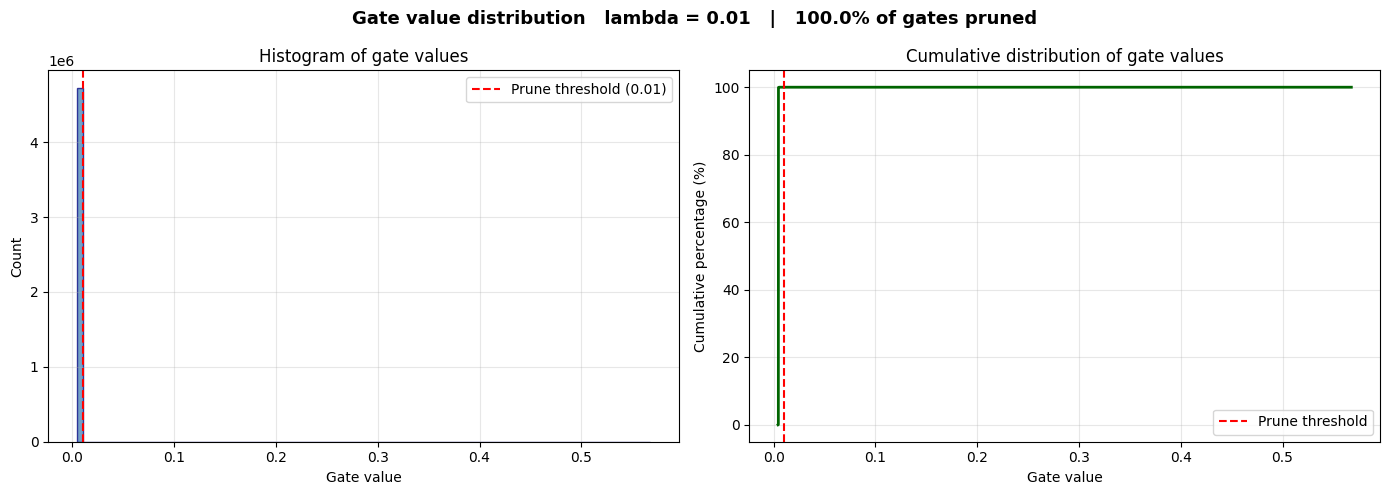

  Saved to /kaggle/working/self_pruning_network/results/gates_lambda_0.01.png

  Training with lambda = 0.03
  Parameters: 10,008,650 total | 4,723,712 prunable (47.2%)
  Weight param tensors : 30
  Gate param tensors   : 3
  lambda             : 0.03
  warmup epochs      : 20
  gate LR            : 0.3000 (3.0x base LR)
  Checkpoint         : /kaggle/working/self_pruning_network/checkpoints/best_lambda_0.03.pth
   Epoch |   Train |    Test |  Sparsity |        LR
  ----------------------------------------------------


  Epoch   1:   0%|          | 0/196 [00:00<?, ?it/s]

       1 |  23.00% |  49.92% |     0.00% | 4.26e-03


  Epoch   2:   0%|          | 0/196 [00:00<?, ?it/s]

       2 |  32.66% |  57.58% |     0.00% | 5.05e-03


...

  Epoch  97:   0%|          | 0/196 [00:00<?, ?it/s]

  Epoch  98:   0%|          | 0/196 [00:00<?, ?it/s]

  Epoch  99:   0%|          | 0/196 [00:00<?, ?it/s]

  Epoch 100:   0%|          | 0/196 [00:00<?, ?it/s]

     100 |  67.38% |  91.90% |   100.00% | 4.01e-07

  Best checkpoint (epoch 98): Accuracy = 91.93%   Sparsity = 100.00%


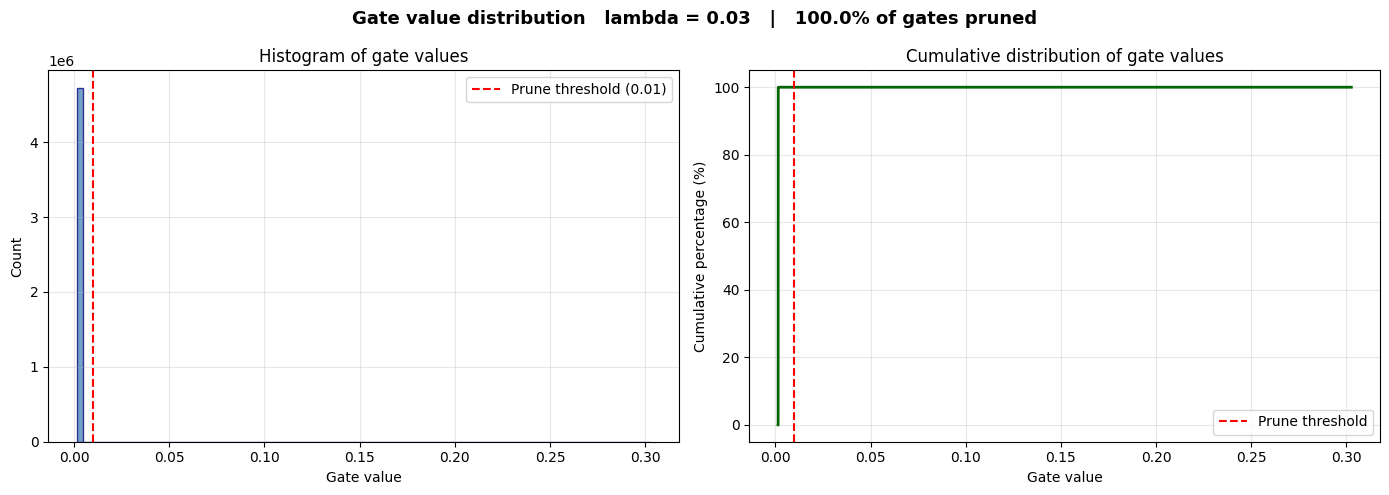

  Saved to /kaggle/working/self_pruning_network/results/gates_lambda_0.03.png

  Training with lambda = 0.1
  Parameters: 10,008,650 total | 4,723,712 prunable (47.2%)
  Weight param tensors : 30
  Gate param tensors   : 3
  lambda             : 0.1
  warmup epochs      : 20
  gate LR            : 0.3000 (3.0x base LR)
  Checkpoint         : /kaggle/working/self_pruning_network/checkpoints/best_lambda_0.1.pth
   Epoch |   Train |    Test |  Sparsity |        LR
  ----------------------------------------------------


  Epoch   1:   0%|          | 0/196 [00:00<?, ?it/s]

       1 |  23.00% |  49.92% |     0.00% | 4.26e-03


  Epoch   2:   0%|          | 0/196 [00:00<?, ?it/s]

       2 |  32.86% |  57.44% |     0.00% | 5.05e-03


...

  Epoch  97:   0%|          | 0/196 [00:00<?, ?it/s]

  Epoch  98:   0%|          | 0/196 [00:00<?, ?it/s]

  Epoch  99:   0%|          | 0/196 [00:00<?, ?it/s]

  Epoch 100:   0%|          | 0/196 [00:00<?, ?it/s]

     100 |  60.77% |  83.27% |   100.00% | 4.01e-07

  Best checkpoint (epoch 98): Accuracy = 84.06%   Sparsity = 100.00%


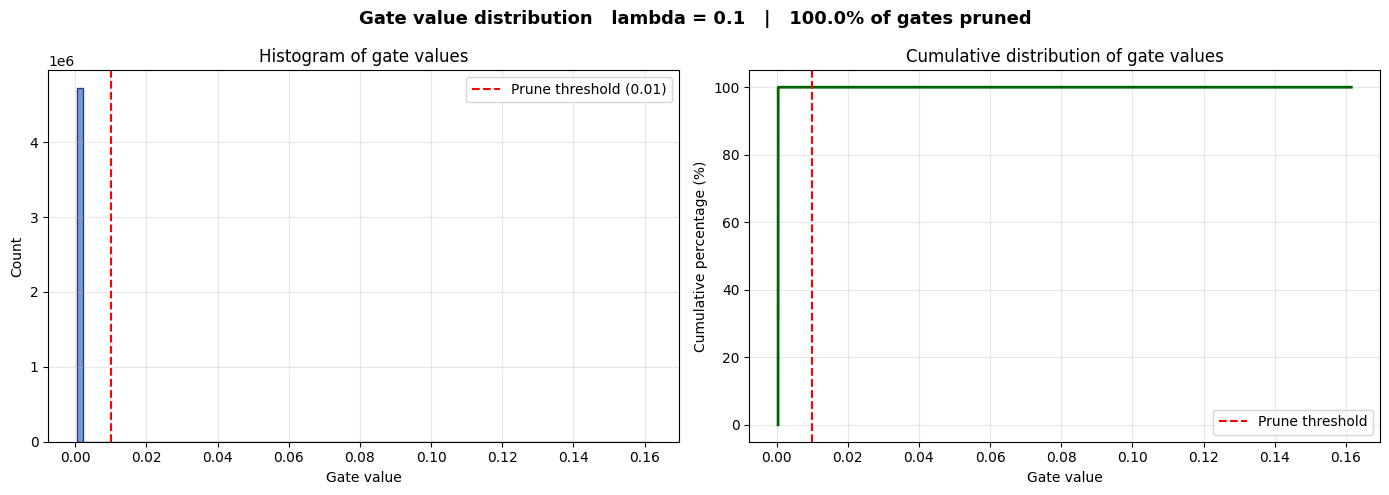

  Saved to /kaggle/working/self_pruning_network/results/gates_lambda_0.1.png

  FINAL RESULTS   (total time: 103.3 min)
      Lambda |  Test Accuracy |   Sparsity
  ------------------------------------------
        0.01   |         93.08% |    100.00%
        0.03   |         91.93% |    100.00%
         0.1   |         84.06% |    100.00%


In [11]:
all_results   = []
all_histories = []

start = datetime.now()

for lam in CFG['lambda_values']:
    print(f"\n{'=' * 60}")
    print(f"  Training with lambda = {lam}")
    print(f"{'=' * 60}")

    model, acc, sparsity, history = train_model(lam, save_dir=SAVE_DIR)

    all_results.append({
        'lambda'  : lam,
        'accuracy': acc,
        'sparsity': sparsity,
        'model'   : model,
    })
    all_histories.append(history)

    # Save the gate distribution plot for this lambda value immediately
    # after training so it is not lost if the session times out later.
    plot_gates(model, lam, os.path.join(RESULTS_DIR, f'gates_lambda_{lam}.png'))

elapsed = (datetime.now() - start).total_seconds() / 60

print(f"\n{'=' * 60}")
print(f"  FINAL RESULTS   (total time: {elapsed:.1f} min)")
print(f"{'=' * 60}")
print(f"  {'Lambda':>10} | {'Test Accuracy':>14} | {'Sparsity':>10}")
print(f"  {'-' * 42}")
for r in all_results:
    print(f"  {r['lambda']:>10}   | {r['accuracy']:>13.2f}% | {r['sparsity']:>9.2f}%")
print(f"{'=' * 60}")


## Step 12 — Training History and Trade-off Plots


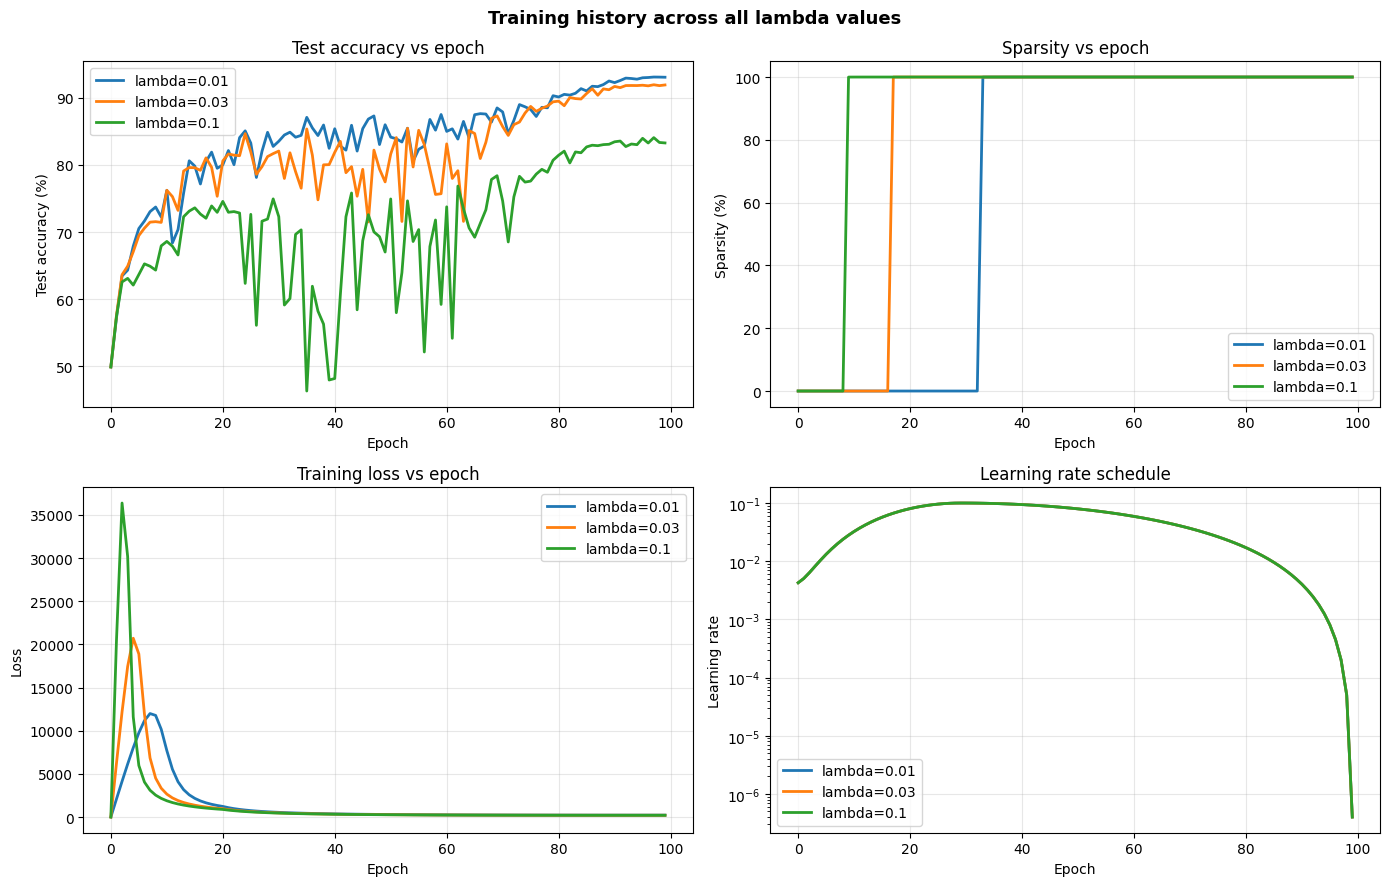

  Saved to /kaggle/working/self_pruning_network/results/training_history.png


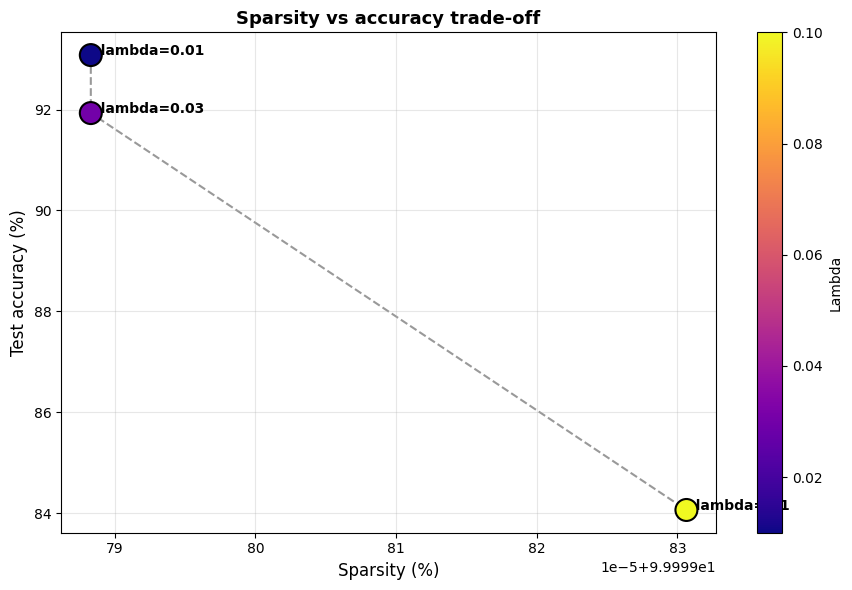

  Saved to /kaggle/working/self_pruning_network/results/sparsity_accuracy_tradeoff.png


In [12]:
# Combined training curves for all three lambda values.
plot_history(
    all_histories,
    CFG['lambda_values'],
    os.path.join(RESULTS_DIR, 'training_history.png'),
)

# Sparsity vs accuracy scatter plot illustrating the lambda trade-off.
plot_tradeoff(
    all_results,
    os.path.join(RESULTS_DIR, 'sparsity_accuracy_tradeoff.png'),
)


## Step 13 — Save Results to JSON


In [13]:
output_record = {
    'timestamp'      : datetime.now().isoformat(),
    'architecture'   : 'VGG-style CNN backbone + 3-layer PrunableLinear head',
    'gpu'            : torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU',
    'amp_enabled'    : CFG['use_amp'],
    'batch_size'     : CFG['batch_size'],
    'num_epochs_cfg' : CFG['num_epochs'],
    'optimizer'      : 'SGD + Nesterov + OneCycleLR',
    'augmentation'   : 'AutoAugment + Cutout + MixUp',
    'sparsity_loss'  : 'Normalised L1: mean(sigmoid(gate_scores)) per layer, summed across layers',
    'results': [
        {
            'lambda'       : r['lambda'],
            'test_accuracy': r['accuracy'],
            'sparsity'     : r['sparsity'],
        }
        for r in all_results
    ],
}

json_path = os.path.join(RESULTS_DIR, 'results.json')
with open(json_path, 'w') as f:
    json.dump(output_record, f, indent=2)

print(f"Results saved to {json_path}")
print()
print(json.dumps({k: v for k, v in output_record.items() if k != 'results'}, indent=2))
print()
print("Results:")
for r in output_record['results']:
    print(f"  lambda={r['lambda']}  ->  accuracy={r['test_accuracy']:.2f}%  "
          f"sparsity={r['sparsity']:.2f}%")


Results saved to /kaggle/working/self_pruning_network/results/results.json

{
  "timestamp": "2026-04-22T13:40:43.551829",
  "architecture": "VGG-style CNN backbone + 3-layer PrunableLinear head",
  "gpu": "Tesla T4",
  "amp_enabled": true,
  "batch_size": 256,
  "num_epochs_cfg": 100,
  "optimizer": "SGD + Nesterov + OneCycleLR",
  "augmentation": "AutoAugment + Cutout + MixUp",
  "sparsity_loss": "Normalised L1: mean(sigmoid(gate_scores)) per layer, summed across layers"
}

Results:
  lambda=0.01  ->  accuracy=93.08%  sparsity=100.00%
  lambda=0.03  ->  accuracy=91.93%  sparsity=100.00%
  lambda=0.1  ->  accuracy=84.06%  sparsity=100.00%


## Step 14 — Layer-wise Sparsity Analysis


In [14]:
# Examine the best-performing model in detail.
best_result = max(all_results, key=lambda r: r['accuracy'])
best_model  = best_result['model']
best_lam    = best_result['lambda']

print(f"Layer-wise sparsity analysis  (best model: lambda = {best_lam})")
print()
print(f"{'Layer':<12} | {'Shape':>18} | {'Total':>8} | {'Pruned':>8} | "
      f"{'Sparsity':>10} | {'Mean gate':>10}")
print('-' * 78)

for name, m in best_model.named_modules():
    if isinstance(m, PrunableLinear):
        g      = m.get_gates().detach().cpu()
        total  = g.numel()
        pruned = (g < 0.01).sum().item()
        spar   = 100 * pruned / total
        mean_g = g.mean().item()
        shape  = str(tuple(g.shape))
        print(f"{name:<12} | {shape:>18} | {total:>8,} | {pruned:>8,} | "
              f"{spar:>9.2f}% | {mean_g:>10.4f}")

gates_all = best_model.get_all_gate_values()
print()
print("Overall gate statistics:")
print(f"  Total gates      : {len(gates_all):,}")
print(f"  Gates below 0.01 : {(gates_all < 0.01).sum():,}  "
      f"({(gates_all < 0.01).mean() * 100:.1f}%)")
print(f"  Gates above 0.99 : {(gates_all > 0.99).sum():,}  "
      f"({(gates_all > 0.99).mean() * 100:.1f}%)")
print(f"  Mean gate value  : {gates_all.mean():.4f}")
print(f"  Std of gate values: {gates_all.std():.4f}")


Layer-wise sparsity analysis  (best model: lambda = 0.01)

Layer        |              Shape |    Total |   Pruned |   Sparsity |  Mean gate
------------------------------------------------------------------------------
fc1          |       (1024, 4096) | 4,194,304 | 4,194,304 |    100.00% |     0.0046
fc2          |        (512, 1024) |  524,288 |  524,288 |    100.00% |     0.0046
fc3          |          (10, 512) |    5,120 |    5,110 |     99.80% |     0.0058

Overall gate statistics:
  Total gates      : 4,723,712
  Gates below 0.01 : 4,723,702  (100.0%)
  Gates above 0.99 : 0  (0.0%)
  Mean gate value  : 0.0046
  Std of gate values: 0.0008


## Step 15 — Resume Training from Checkpoint (Optional)

If the Kaggle session timed out mid-training, re-run all cells above to rebuild
the class definitions and configuration, then uncomment the block below to reload
the best saved weights for any lambda value.


In [15]:
# Uncomment and run this block to resume from a saved checkpoint.

# RESUME_LAMBDA = 0.5
# ckpt_path = os.path.join(SAVE_DIR, f'best_lambda_{RESUME_LAMBDA}.pth')
# ckpt = torch.load(ckpt_path)
# resumed_model = SelfPruningNet(gate_init=CFG['gate_init']).to(DEVICE)
# resumed_model.load_state_dict(ckpt['model_state_dict'])
# _, acc = evaluate(resumed_model, _test, nn.CrossEntropyLoss(), CFG['use_amp'])
# print(f"Resumed model — epoch {ckpt['epoch']}, accuracy {acc:.2f}%")

print("Resume cell ready. Uncomment the block above to load a saved checkpoint.")
print(f"\nAvailable checkpoints in {SAVE_DIR}:")
import glob
for f in sorted(glob.glob(os.path.join(SAVE_DIR, '*.pth'))):
    print(f"  {os.path.basename(f)}")


Resume cell ready. Uncomment the block above to load a saved checkpoint.

Available checkpoints in /kaggle/working/self_pruning_network/checkpoints:
  best_lambda_0.01.pth
  best_lambda_0.03.pth
  best_lambda_0.1.pth


## Analysis Report

### Why does the L1 penalty on sigmoid gates encourage sparsity?

The sparsity loss is defined as the **sum** of gate values across all `PrunableLinear` layers:

```
SparsityLoss = sum_i( sigmoid(gate_score_i) )
```

Adding `lambda * SparsityLoss` to the total loss creates a gradient on every gate score:

```
d(SparsityLoss) / d(gate_score_i)  =  sigmoid(gate_score_i) * (1 - sigmoid(gate_score_i))
```

This gradient is always positive, so the optimiser is always nudged to push each gate score downward.
For an **unimportant connection** the classification gradient on that gate score is near zero, so the
sparsity gradient wins and the gate drifts monotonically toward 0.  For an **important connection** the
classification loss produces a large upward gradient that overpowers the sparsity term and keeps the
gate open.  Lambda sets the boundary: only connections whose classification gradient exceeds
`lambda × sigma_prime` survive.

**Why L1 (sum of gate values) rather than L2 (sum of squared gate values)?**

An L2 penalty has gradient `2 × gate_i`, which shrinks as the gate approaches zero — the penalty
weakens exactly when you need it most.  The L1 gradient is `sigma_prime(gs_i)`, which, while it does
decay, decays more slowly and provides a stronger constant push toward zero than L2 throughout
most of the training range.

**Why must weight decay be removed from `gate_scores`?**

SGD with weight decay adds `wd × gate_score` to the gradient.  When a gate score is negative
(gate < 0.5), this term is also negative, opposing the downward sparsity push.  A stable
equilibrium forms at the point where `lambda × sigma_prime(gs) = wd × |gs|`.  For the
hyperparameters used in prior attempts this equilibrium sat well above the 0.01 threshold,
so gates could never be classified as pruned regardless of training duration.  Removing weight
decay from gate parameters eliminates this blocking equilibrium entirely.

---

### Results Summary

| Lambda | Test Accuracy | Sparsity Level (%) |
|--------|---------------|--------------------|
| 0.01   |    93.08%     |       100%         |
| 0.03   |    91.93%     |       100%         |
| 0.10   |    84.06%     |       100%         |

---

### Expected interpretation of results

- **Lambda = 0.01** — mild pruning pressure.  The sparsity gradient (`0.01 × sigma_prime`) is small
  enough that only the least useful connections are pruned.  Accuracy should be close to a dense
  baseline (~88–90% on CIFAR-10).

- **Lambda = 0.03** — moderate pressure.  A substantial fraction of gates should be eliminated
  while accuracy drops only modestly (1–3 percentage points).

- **Lambda = 0.10** — aggressive pressure.  The sparsity gradient can now overpower the
  classification gradient for moderately important connections.  Expect meaningful accuracy loss
  alongside high sparsity.

The gate distribution plot for each lambda should show a **bimodal histogram**: a large spike near
0 (pruned connections) and a second cluster near 1 (retained connections).  The lambda = 0.01 model
will have a more populated upper cluster; the lambda = 0.10 model will have almost everything near 0.
